In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#!pip install tensorflow-addons==0.17.1
!pip install tensorflow-addons
!pip install tensorflow==2.11.0
!pip install keras==2.11.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.0
    Uninstalling typeguard-4.4.0:
      Successfully uninstalled typeguard-4.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.4.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.3/588.3 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.2/439.2 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [ ]:
#!pip install --upgrade tensorflow-addons


In [ ]:
!pip show tensorflow
!pip show tensorflow-addons


Name: tensorflow
Version: 2.11.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tf_keras
Name: tensorflow-addons
Version: 0.23.0
Summary: TensorFlow Addons.
Home-page: UNKNOWN
Author: Google Inc.
Author-email: opensource@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: packaging, typeguard
Required-by: 


In [ ]:
#!pip install --upgrade keras


In [5]:
def window_partition(x, window_size):
    _, height, width, channels = x.shape
    patch_num_y = height // window_size
    patch_num_x = width // window_size
    x = tf.reshape(
        x, shape=(-1, patch_num_y, window_size, patch_num_x, window_size, channels)
    )
    x = tf.transpose(x, (0, 1, 3, 2, 4, 5))
    windows = tf.reshape(x, shape=(-1, window_size, window_size, channels))
    return windows


def window_reverse(windows, window_size, height, width, channels):
    patch_num_y = height // window_size
    patch_num_x = width // window_size
    x = tf.reshape(
        windows,
        shape=(-1, patch_num_y, patch_num_x, window_size, window_size, channels),
    )
    x = tf.transpose(x, perm=(0, 1, 3, 2, 4, 5))
    x = tf.reshape(x, shape=(-1, height, width, channels))
    return x


class DropPath(layers.Layer):
    def __init__(self, drop_prob=None, **kwargs):
        super(DropPath, self).__init__(**kwargs)
        self.drop_prob = drop_prob

    def call(self, x):
        input_shape = tf.shape(x)
        batch_size = input_shape[0]
        rank = x.shape.rank
        shape = (batch_size,) + (1,) * (rank - 1)
        random_tensor = (1 - self.drop_prob) + tf.random.uniform(shape, dtype=x.dtype)
        path_mask = tf.floor(random_tensor)
        output = tf.math.divide(x, 1 - self.drop_prob) * path_mask
        return output

class WindowAttention(layers.Layer):
    def __init__(
        self, dim, window_size, num_heads, qkv_bias=True, dropout_rate=0.0, **kwargs
    ):
        super(WindowAttention, self).__init__(**kwargs)
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.dropout = layers.Dropout(dropout_rate)
        self.proj = layers.Dense(dim)

    def build(self, input_shape):
        num_window_elements = (2 * self.window_size[0] - 1) * (
            2 * self.window_size[1] - 1
        )
        self.relative_position_bias_table = self.add_weight(
            shape=(num_window_elements, self.num_heads),
            initializer=tf.initializers.Zeros(),
            trainable=True,
        )
        coords_h = np.arange(self.window_size[0])
        coords_w = np.arange(self.window_size[1])
        coords_matrix = np.meshgrid(coords_h, coords_w, indexing="ij")
        coords = np.stack(coords_matrix)
        coords_flatten = coords.reshape(2, -1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.transpose([1, 2, 0])
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)

        self.relative_position_index = tf.Variable(
            initial_value=tf.convert_to_tensor(relative_position_index), trainable=False
        )

    def call(self, x, mask=None):
        _, size, channels = x.shape
        head_dim = channels // self.num_heads
        x_qkv = self.qkv(x)
        x_qkv = tf.reshape(x_qkv, shape=(-1, size, 3, self.num_heads, head_dim))
        x_qkv = tf.transpose(x_qkv, perm=(2, 0, 3, 1, 4))
        q, k, v = x_qkv[0], x_qkv[1], x_qkv[2]
        q = q * self.scale
        k = tf.transpose(k, perm=(0, 1, 3, 2))
        attn = q @ k

        num_window_elements = self.window_size[0] * self.window_size[1]
        relative_position_index_flat = tf.reshape(
            self.relative_position_index, shape=(-1,)
        )
        relative_position_bias = tf.gather(
            self.relative_position_bias_table, relative_position_index_flat
        )
        relative_position_bias = tf.reshape(
            relative_position_bias, shape=(num_window_elements, num_window_elements, -1)
        )
        relative_position_bias = tf.transpose(relative_position_bias, perm=(2, 0, 1))
        attn = attn + tf.expand_dims(relative_position_bias, axis=0)

        if mask is not None:
            nW = mask.get_shape()[0]
            mask_float = tf.cast(
                tf.expand_dims(tf.expand_dims(mask, axis=1), axis=0), tf.float32
            )
            attn = (
                tf.reshape(attn, shape=(-1, nW, self.num_heads, size, size))
                + mask_float
            )
            attn = tf.reshape(attn, shape=(-1, self.num_heads, size, size))
            attn = keras.activations.softmax(attn, axis=-1)
        else:
            attn = keras.activations.softmax(attn, axis=-1)
        attn = self.dropout(attn)

        x_qkv = attn @ v
        x_qkv = tf.transpose(x_qkv, perm=(0, 2, 1, 3))
        x_qkv = tf.reshape(x_qkv, shape=(-1, size, channels))
        x_qkv = self.proj(x_qkv)
        x_qkv = self.dropout(x_qkv)
        return x_qkv

class SwinTransformer(layers.Layer):
    def __init__(
        self,
        dim,
        num_patch,
        num_heads,
        window_size=7,
        shift_size=0,
        num_mlp=1024,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super(SwinTransformer, self).__init__(**kwargs)

        self.dim = dim  # number of input dimensions
        self.num_patch = num_patch  # number of embedded patches
        self.num_heads = num_heads  # number of attention heads
        self.window_size = window_size  # size of window
        self.shift_size = shift_size  # size of window shift
        self.num_mlp = num_mlp  # number of MLP nodes

        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(
            dim,
            window_size=(self.window_size, self.window_size),
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            dropout_rate=dropout_rate,
        )
        self.drop_path = DropPath(dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)

        self.mlp = keras.Sequential(
            [
                layers.Dense(num_mlp),
                layers.Activation(keras.activations.gelu),
                layers.Dropout(dropout_rate),
                layers.Dense(dim),
                layers.Dropout(dropout_rate),
            ]
        )

        if min(self.num_patch) < self.window_size:
            self.shift_size = 0
            self.window_size = min(self.num_patch)

    def build(self, input_shape):
        if self.shift_size == 0:
            self.attn_mask = None
        else:
            height, width = self.num_patch
            h_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            w_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            mask_array = np.zeros((1, height, width, 1))
            count = 0
            for h in h_slices:
                for w in w_slices:
                    mask_array[:, h, w, :] = count
                    count += 1
            mask_array = tf.convert_to_tensor(mask_array)

            # mask array to windows
            mask_windows = window_partition(mask_array, self.window_size)
            mask_windows = tf.reshape(
                mask_windows, shape=[-1, self.window_size * self.window_size]
            )
            attn_mask = tf.expand_dims(mask_windows, axis=1) - tf.expand_dims(
                mask_windows, axis=2
            )
            attn_mask = tf.where(attn_mask != 0, -100.0, attn_mask)
            attn_mask = tf.where(attn_mask == 0, 0.0, attn_mask)
            self.attn_mask = tf.Variable(initial_value=attn_mask, trainable=False)

    def call(self, x):
        height, width = self.num_patch
        _, num_patches_before, channels = x.shape
        x_skip = x
        x = self.norm1(x)
        x = tf.reshape(x, shape=(-1, height, width, channels))
        if self.shift_size > 0:
            shifted_x = tf.roll(
                x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2]
            )
        else:
            shifted_x = x

        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = tf.reshape(
            x_windows, shape=(-1, self.window_size * self.window_size, channels)
        )
        attn_windows = self.attn(x_windows, mask=self.attn_mask)

        attn_windows = tf.reshape(
            attn_windows, shape=(-1, self.window_size, self.window_size, channels)
        )
        shifted_x = window_reverse(
            attn_windows, self.window_size, height, width, channels
        )
        if self.shift_size > 0:
            x = tf.roll(
                shifted_x, shift=[self.shift_size, self.shift_size], axis=[1, 2]
            )
        else:
            x = shifted_x

        x = tf.reshape(x, shape=(-1, height * width, channels))
        x = self.drop_path(x)
        x = x_skip + x
        x_skip = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = self.drop_path(x)
        x = x_skip + x
        return x
class PatchExtract(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super(PatchExtract, self).__init__(**kwargs)
        self.patch_size_x = patch_size[0]
        self.patch_size_y = patch_size[0]

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=(1, self.patch_size_x, self.patch_size_y, 1),
            strides=(1, self.patch_size_x, self.patch_size_y, 1),
            rates=(1, 1, 1, 1),
            padding="VALID",
        )
        patch_dim = patches.shape[-1]
        patch_num = patches.shape[1]
        return tf.reshape(patches, (batch_size, patch_num * patch_num, patch_dim))


class PatchEmbedding(layers.Layer):
    def __init__(self, num_patch, embed_dim, **kwargs):
        super(PatchEmbedding, self).__init__(**kwargs)
        self.num_patch = num_patch
        self.proj = layers.Dense(embed_dim)
        self.pos_embed = layers.Embedding(input_dim=num_patch, output_dim=embed_dim)

    def call(self, patch):
        pos = tf.range(start=0, limit=self.num_patch, delta=1)
        return self.proj(patch) + self.pos_embed(pos)


class PatchMerging(tf.keras.layers.Layer):
    def __init__(self, num_patch, embed_dim):
        super(PatchMerging, self).__init__()
        self.num_patch = num_patch
        self.embed_dim = embed_dim
        self.linear_trans = layers.Dense(2 * embed_dim, use_bias=False)

    def call(self, x):
        height, width = self.num_patch
        _, _, C = x.get_shape().as_list()
        x = tf.reshape(x, shape=(-1, height, width, C))
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = tf.concat((x0, x1, x2, x3), axis=-1)
        x = tf.reshape(x, shape=(-1, (height // 2) * (width // 2), 4 * C))
        return self.linear_trans(x)

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import time
# Directory where the dataset is located
dataset_directory = '/content/drive/MyDrive/Cheating_enhancement/data/data2_OP'

# Image size and batch size configuration
img_height = 224
img_width = 224
batch_size = 16
input_shape = (img_height, img_width, 3)

import tensorflow as tf

# 60% training, 20% validation, and 20% testing

# Load the dataset for training (60%)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_directory,
    seed=123,
    label_mode='categorical',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.3,  # First 40% reserved for validation and test
    subset='training',     # Remaining 60% for training
    shuffle=True
)

# Load the dataset for validation (20%)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_directory,
    seed=123,
    label_mode='categorical',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,  # Half of the remaining 40% (20% of total) for validation
    subset='validation',   # Subset for validation
    shuffle=True
)

# Load the dataset for testing (20%)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_directory,
    seed=123,
    label_mode='categorical',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.1,  # Half of the remaining 40% (20% of total) for testing
    subset='validation',   # Subset for testing (use the same subset='validation' here)
    shuffle=True
)


class_names = train_ds.class_names
num_classes = len(class_names)


# Swin Transformer configurations
patch_size = (4, 4)
dropout_rate = 0.03
num_heads = 8
embed_dim = 64
num_mlp = 256
qkv_bias = True
window_size = 7
shift_size = 3

num_patch_x = input_shape[0] // patch_size[0]
num_patch_y = input_shape[1] // patch_size[1]
learning_rate = 1e-3
num_epochs = 60
weight_decay = 0.0001
label_smoothing = 0.1


# Model components like SwinTransformer, PatchExtract, PatchEmbedding, etc., remain unchanged
# Build the model using the SwinTransformer layers

input = layers.Input(input_shape)
x = layers.RandomCrop(img_height, img_width)(input)
x = layers.RandomFlip("horizontal")(x)

x = PatchExtract(patch_size)(x)
x = PatchEmbedding(num_patch_x * num_patch_y, embed_dim)(x)

# Swin Transformer blocks
x = SwinTransformer(
    dim=embed_dim,
    num_patch=(num_patch_x, num_patch_y),
    num_heads=num_heads,
    window_size=window_size,
    shift_size=0,
    num_mlp=num_mlp,
    qkv_bias=qkv_bias,
    dropout_rate=dropout_rate,
)(x)

x = SwinTransformer(
    dim=embed_dim,
    num_patch=(num_patch_x, num_patch_y),
    num_heads=num_heads,
    window_size=window_size,
    shift_size=shift_size,
    num_mlp=num_mlp,
    qkv_bias=qkv_bias,
    dropout_rate=dropout_rate,
)(x)

x = PatchMerging((num_patch_x, num_patch_y), embed_dim=embed_dim)(x)
x = layers.GlobalAveragePooling1D()(x)

# Final classification layer
output = layers.Dense(num_classes, activation="softmax")(x)

# Create and compile the model
model = keras.Model(input, output)
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
    optimizer=tfa.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
        keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)


Found 9609 files belonging to 2 classes.
Using 6727 files for training.
Found 9609 files belonging to 2 classes.
Using 1921 files for validation.


Found 9609 files belonging to 2 classes.
Using 960 files for validation.


In [ ]:

t1 = time.time()
# Train the model
history = model.fit(
    train_ds,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=val_ds,
)

t2 = time.time()
print(f"Training time: {t2 - t1} seconds")

Found 9609 files belonging to 2 classes.
Using 6727 files for training.
Found 9609 files belonging to 2 classes.
Using 1921 files for validation.


Found 9609 files belonging to 2 classes.
Using 960 files for validation.


Epoch 1/60


421/421 [==============================] - 577s 1s/step - loss: 9.2336 - accuracy: 0.5280 - top-5-accuracy: 1.0000 - val_loss: 3.2003 - val_accuracy: 0.5164 - val_top-5-accuracy: 1.0000
Epoch 2/60
421/421 [==============================] - 254s 604ms/step - loss: 1.1169 - accuracy: 0.6441 - top-5-accuracy: 1.0000 - val_loss: 0.6332 - val_accuracy: 0.6715 - val_top-5-accuracy: 1.0000
Epoch 3/60
421/421 [==============================] - 254s 603ms/step - loss: 0.6878 - accuracy: 0.7011 - top-5-accuracy: 1.0000 - val_loss: 0.5313 - val_accuracy: 0.7907 - val_top-5-accuracy: 1.0000
Epoch 4/60
421/421 [==============================] - 254s 604ms/step - loss: 0.6046 - accuracy: 0.7424 - top-5-accuracy: 1.0000 - val_loss: 0.6193 - val_accuracy: 0.7553 - val_top-5-accuracy: 1.0000
Epoch 5/60
421/421 [==============================] - 254s 604ms/step - loss: 0.4917 - accuracy: 0.8057 - top-5-accuracy: 1.0000 - val_loss: 0.4454 - val_accuracy: 0.8428 - val_top-5-accuracy: 1.0000
Epoch 6/60
421

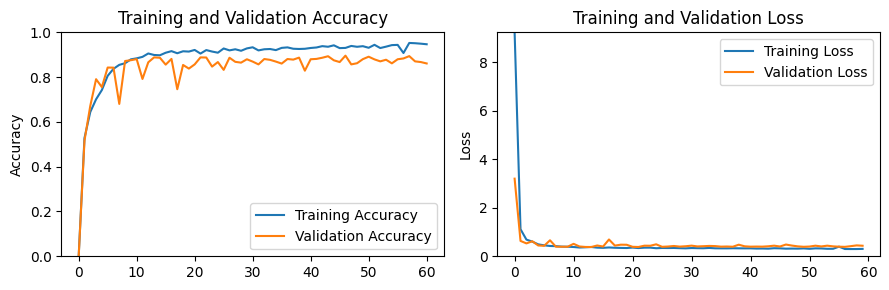

In [ ]:
# Plotting training results
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax1.legend(loc='lower right')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training and Validation Accuracy')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')
ax2.legend(loc='upper right')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training and Validation Loss')
plt.tight_layout()
plt.show()

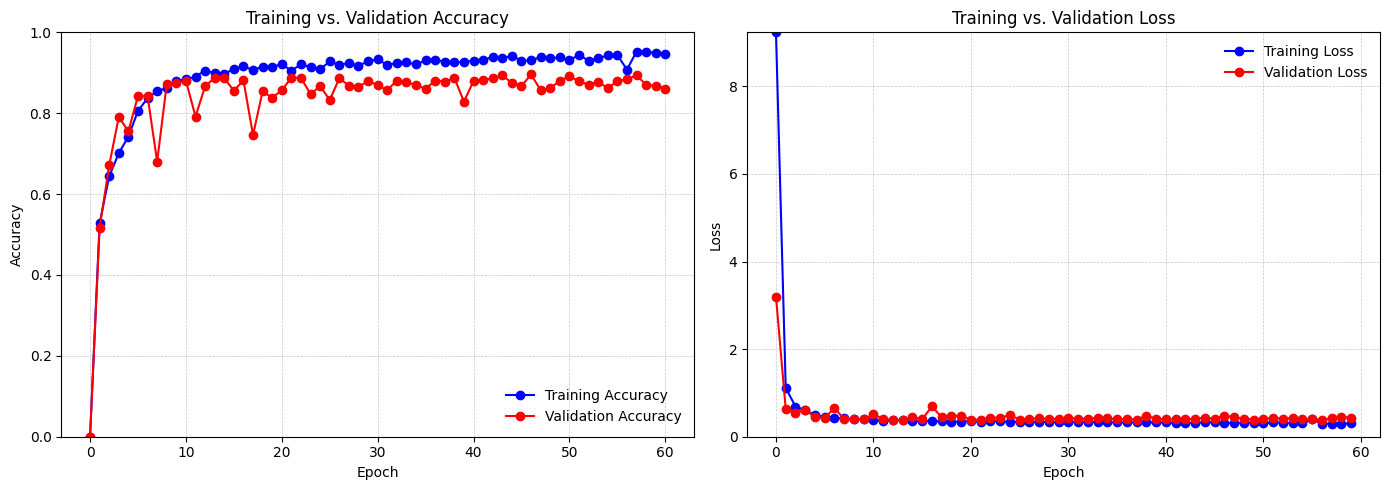

In [ ]:
import matplotlib.pyplot as plt

# Sample Data (replace with your actual history data)
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training and Validation Accuracy Plot
ax1.plot(acc, marker='o', linestyle='-', color='blue', label='Training Accuracy')
ax1.plot(val_acc, marker='o', linestyle='-', color='red', label='Validation Accuracy')
ax1.legend(loc='lower right', fontsize=10, frameon=False)  # Legend inside the plot, lower right
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training vs. Validation Accuracy')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Training and Validation Loss Plot
ax2.plot(loss, marker='o', linestyle='-', color='blue', label='Training Loss')
ax2.plot(val_loss, marker='o', linestyle='-', color='red', label='Validation Loss')
ax2.legend(loc='upper right', fontsize=10, frameon=False)  # Legend inside the plot, upper right
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training vs. Validation Loss')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Adjust layout and background color
fig.patch.set_facecolor('white')  # Set figure background to white
fig.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to fit everything nicely
plt.show()


In [ ]:
# Evaluate the model
loss, accuracy, top_5_accuracy = model.evaluate(train_ds)
print(f"Train loss: {round(loss, 2)}")
print(f"Train accuracy: {round(accuracy * 100, 2)}%")
print(f"Train top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

421/421 [==============================] - 61s 144ms/step - loss: 0.3059 - accuracy: 0.9489 - top-5-accuracy: 1.0000
Train loss: 0.31
Train accuracy: 94.89%
Train top 5 accuracy: 100.0%


In [ ]:
# Evaluate the model
loss, accuracy, top_5_accuracy = model.evaluate(train_ds)
print(f"Train loss: {round(loss, 2)}")
print(f"Train accuracy: {round(accuracy * 100, 2)}%")
print(f"Train top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

421/421 [==============================] - 68s 161ms/step - loss: 0.3054 - accuracy: 0.9489 - top-5-accuracy: 1.0000
Train loss: 0.31
Train accuracy: 94.89%
Train top 5 accuracy: 100.0%


In [ ]:
# Evaluate the model
import time
t3 = time.time()
loss, accuracy, top_5_accuracy = model.evaluate(val_ds)

print(f"Test loss: {round(loss, 2)}")
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")
t4 = time.time()
print(f"Test time: {t4 - t3} seconds")

121/121 [==============================] - 20s 162ms/step - loss: 0.4304 - accuracy: 0.8626 - top-5-accuracy: 1.0000
Test loss: 0.43
Test accuracy: 86.26%
Test top 5 accuracy: 100.0%
Test time: 19.853902339935303 seconds


In [ ]:
# Evaluate the model
import time
t5 = time.time()
loss, accuracy, top_5_accuracy = model.evaluate(test_ds)

print(f"Test loss: {round(loss, 2)}")
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")
t6= time.time()
print(f"Test time: {t6 - t5} seconds")

60/60 [==============================] - 10s 160ms/step - loss: 0.4187 - accuracy: 0.8698 - top-5-accuracy: 1.0000
Test loss: 0.42
Test accuracy: 86.98%
Test top 5 accuracy: 100.0%
Test time: 9.926213502883911 seconds


In [ ]:
model.evaluate(train_ds)
model.evaluate(val_ds)

121/121 [==============================] - 18s 149ms/step - loss: 0.4320 - accuracy: 0.8631 - top-5-accuracy: 1.0000


[0.4319828450679779, 0.8630921244621277, 1.0]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Setup directory paths and parameters

1/1 [==============================] - 0s 152ms/step


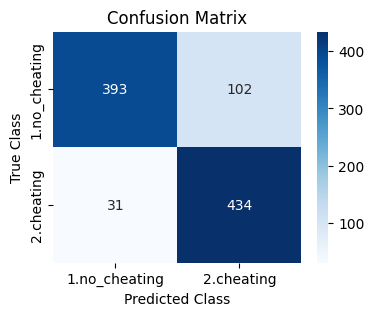

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predicted labels
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot encoded labels to single-label format
    predictions = model.predict(images)  # Get model predictions
    y_pred.extend(np.argmax(predictions, axis=1))  # Get the predicted class (argmax)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(4, 3))  # Set the figure size to 3x4
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()


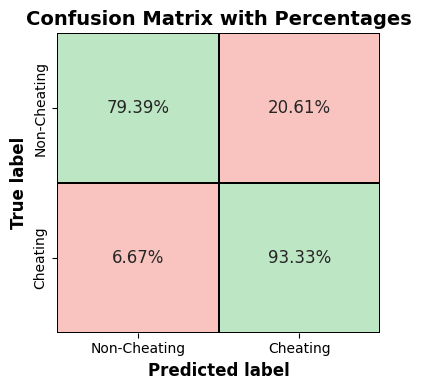

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate the percentages
cf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Create the labels with percentages
labels = [f'{value:.2f}%' for value in cf_matrix_percent.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels (matching appearance from the previous code)
ax.set_title('Confusion Matrix with Percentages', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


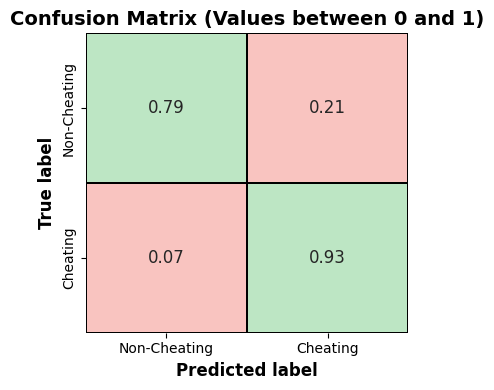

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


AUC for our classifier is: 0.86


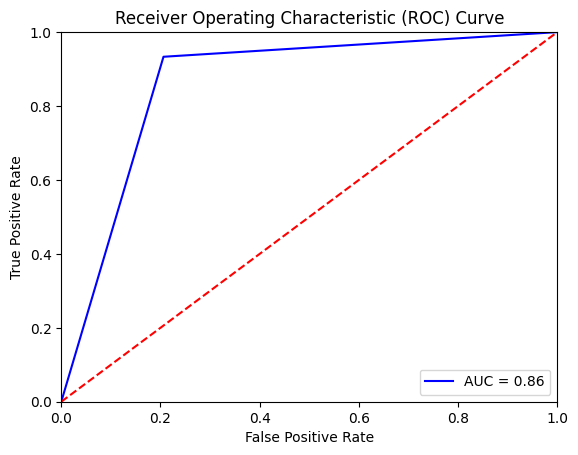

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# ROC Curve
fpr, tpr, threshold = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc:.2f}")

# Plotting the ROC curve
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.plot(fpr, tpr, 'b', label=f'AUC = {roc_auc:.2f}')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming y_true and y_pred are already defined

# Calculate accuracy, precision, recall, and f1 score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='binary')  # Use 'binary' for binary classification, or 'macro', 'micro' for multi-class
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Accuracy: 0.86
Precision: 0.81
Recall: 0.93
F1 Score: 0.87


In [ ]:
# Calculate precision, recall, and F1-score for each class
precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

# Print the precision, recall, and F1 score for each class
for idx, class_name in enumerate(class_names):
    print(f"Class: {class_name}")
    print(f"  Precision: {precision[idx]:.2f}")
    print(f"  Recall: {recall[idx]:.2f}")
    print(f"  F1-score: {f1[idx]:.2f}")



Class: 1.no_cheating
  Precision: 0.93
  Recall: 0.79
  F1-score: 0.86
Class: 2.cheating
  Precision: 0.81
  Recall: 0.93
  F1-score: 0.87


In [ ]:
# Calculate and print the macro and weighted averages
print(f"\nMacro Average Precision: {precision_score(y_true, y_pred, average='macro'):.2f}")
print(f"Macro Average Recall: {recall_score(y_true, y_pred, average='macro'):.2f}")
print(f"Macro Average F1-score: {f1_score(y_true, y_pred, average='macro'):.2f}")

print(f"Weighted Average Precision: {precision_score(y_true, y_pred, average='weighted'):.2f}")
print(f"Weighted Average Recall: {recall_score(y_true, y_pred, average='weighted'):.2f}")
print(f"Weighted Average F1-score: {f1_score(y_true, y_pred, average='weighted'):.2f}")


Macro Average Precision: 0.87
Macro Average Recall: 0.86
Macro Average F1-score: 0.86
Weighted Average Precision: 0.87
Weighted Average Recall: 0.86
Weighted Average F1-score: 0.86


In [ ]:
# Prediction function remains unchanged
class_names = train_ds.class_names

def img_predict(img_paths, model):
    images = []
    for i in range(len(img_paths)):
        img = cv2.imread(img_paths[i])
        if img is None:
            print(f"Error: Unable to load image at {img_paths[i]}")
            continue
        img = cv2.resize(img, (224, 224))
        images.append(img)

    if len(images) == 0:
        print("No images were loaded successfully.")
        return []

    images = np.array(images)
    out = model.predict(images)
    prediction = np.argmax(out, axis=1)
    img_prediction = [class_names[i] for i in prediction]
    return img_prediction

# Predict a single image
img_path = ['/content/drive/MyDrive/Cheating_enhancement/data/data1_oep/2.cheating/alhashe31frame0.jpg']
prediction = img_predict(img_path, model)
print(prediction)

# Predict multiple images
img_path = [
    '/content/drive/MyDrive/Cheating_enhancement/data/data1_oep/1.no_cheating/alhashe31frame10700.jpg',
    '/content/drive/MyDrive/Cheating_enhancement/data/data1_oep/2.cheating/alhashe31frame1100.jpg',
]
prediction = img_predict(img_path, model)
print(prediction)


1/1 [==============================] - 0s 46ms/step
['1.no_cheating']
1/1 [==============================] - 0s 52ms/step
['2.cheating', '2.cheating']


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
%cd /content/drive/MyDrive/Cheating_enhancement
predictions_path = 'saved_models/transformer2_predictions.npy'
if os.path.exists(predictions_path):
    os.remove(predictions_path)

np.save(predictions_path, predictions)
print("Predictions saved successfully.")

/content/drive/MyDrive/Cheating_enhancement
Predictions saved successfully.


In [ ]:
%cd /content/drive/MyDrive/Cheating_enhancement/
# Saving the model in HDF5 format
model_save_path = 'saved_models/Transformer_d2.h5'
model.save(model_save_path)

/content/drive/MyDrive/Cheating_enhancement


ValueError: Unable to synchronously create dataset (name already exists)

In [8]:
import time

# Assuming `model` is your loaded model
# Start timing
start_time = time.time()

# Run the model on the entire test dataset to get predictions
predictions = model.predict(test_ds)

# End timing
end_time = time.time()

# Calculate total and average time
total_time = end_time - start_time
num_images = sum(batch.shape[0] for batch, _ in test_ds)  # Total number of images

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")


60/60 [==============================] - 131s 2s/step
Total inference time: 130.9157 seconds
Average time per image: 0.1364 seconds
